In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [64]:
df=pd.read_csv('dataset.csv')
df

,Age,Income,Experience,Education,City,Target
0,NaN,35627.0,9.0,Bachelors,Delhi,1
1,35.0,33792.0,3.0,Masters,Mumbai,1
2,28.0,NaN,21.0,Bachelors,Pune,0
3,120.0,68021.0,17.0,NaN,Bangalore,1
4,39.0,33433.0,11.0,PhD,NaN,1
5,43.0,68001.0,1.0,Masters,Delhi,0
6,NaN,36016.0,9.0,Bachelors,Mumbai,1
7,31.0,NaN,3.0,Bachelors,Pune,0
8,44.0,450000.0,13.0,NaN,Bangalore,1
9,44.0,81193.0,NaN,Masters,Delhi,1


In [65]:
x= df.drop(columns='Target')
y= df['Target']

In [66]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [67]:
xtrain

,Age,Income,Experience,Education,City
28,29.0,36653.0,0.0,Bachelors,Delhi
24,35.0,600000.0,12.0,NaN,Delhi
12,22.0,79638.0,60.0,Masters,Pune
0,NaN,35627.0,9.0,Bachelors,Delhi
4,39.0,33433.0,11.0,PhD,NaN
16,41.0,84900.0,20.0,Bachelors,NaN
5,43.0,68001.0,1.0,Masters,Delhi
13,44.0,48483.0,22.0,NaN,Bangalore
11,42.0,80387.0,7.0,Bachelors,Mumbai
22,48.0,51531.0,23.0,Bachelors,Bangalore


<Axes: >

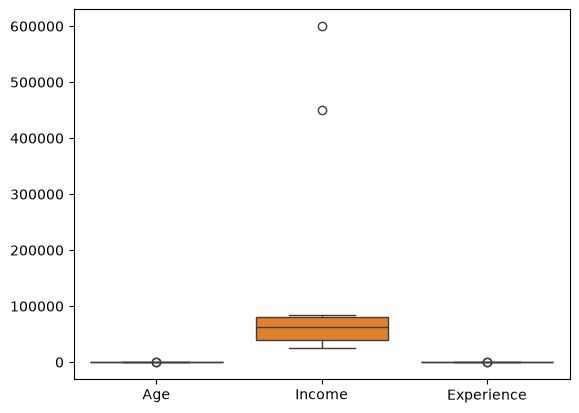

In [68]:
sns.boxplot(x)

In [69]:
numerical_column=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaling',RobustScaler())
    ]
)
categorical_column=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [70]:
xtrain

,Age,Income,Experience,Education,City
28,29.0,36653.0,0.0,Bachelors,Delhi
24,35.0,600000.0,12.0,NaN,Delhi
12,22.0,79638.0,60.0,Masters,Pune
0,NaN,35627.0,9.0,Bachelors,Delhi
4,39.0,33433.0,11.0,PhD,NaN
16,41.0,84900.0,20.0,Bachelors,NaN
5,43.0,68001.0,1.0,Masters,Delhi
13,44.0,48483.0,22.0,NaN,Bangalore
11,42.0,80387.0,7.0,Bachelors,Mumbai
22,48.0,51531.0,23.0,Bachelors,Bangalore


In [71]:
processing=ColumnTransformer(
    transformers=[
        ('numerical_pipeline',numerical_column,['Age','Income','Experience']),
        ('categorical_pipeline',categorical_column,['Education','City'])
    ]
)

In [72]:
main_pipeline=Pipeline(
    steps=[
        ('pre',processing),
        ('model',LinearRegression())
    ]
)
main_pipeline.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Age','Income','Experience','Education','City']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('categorical_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis